# MOSAIC-GNN — pan-cancer multi-omics graph neural network

**M**ulti-**O**mic **S**tructure-**A**daptive **I**nterpretable **C**ross-cancer GNN
on TCGA (BLCA, LIHC, SKCM, THCA).

Each patient is encoded as a *graph of genes* (mutation / CNA / expression /
methylation channels on nodes, PPI + pathway + co-alteration edges), pooled into
functional modules, and the resulting patient vector becomes a node in a
*learned patient-similarity graph*. A cohort-adversarial split of the latent
(`z_shared` vs `z_specific`) is what makes the representation transfer to a
held-out cancer type rather than memorising the cohort.

Heads: stage/grade/subtype classification, Cox risk, and a discrete-time hazard
curve — trained jointly.

### How to use this notebook
1. Run **Setup** and **Configuration**.
2. **Explore** the cohorts.
3. **Single fold** trains one model quickly and produces the figures.
4. **Full experiments** (CV, baselines, ablations, leave-one-cancer-out) are
   guarded by `RUN_FULL` — flip it on when you have GPU time.
5. **Interpretation** produces the gene / module tables and the paper figures.

## 1. Setup

In [1]:
import os, sys, subprocess, glob, warnings, json, time
warnings.filterwarnings("ignore")

# --- locate the `mosaic` package -----------------------------------------
CANDIDATES = [
    ".", "..", "/kaggle/working", "/kaggle/working/mosaic-gnn",
    *glob.glob("/kaggle/input/*"), *glob.glob("/kaggle/input/*/*"),
]
PKG_ROOT = next((os.path.abspath(p) for p in CANDIDATES
                 if os.path.isfile(os.path.join(p, "mosaic", "config.py"))), None)

if PKG_ROOT is None:
    # Fall back to a zip uploaded as a Kaggle dataset or into /kaggle/working.
    zips = glob.glob("/kaggle/input/**/mosaic*gnn*.zip", recursive=True) \
         + glob.glob("**/mosaic*gnn*.zip", recursive=True)
    if zips:
        import zipfile
        dest = "/kaggle/working/mosaic-gnn" if os.path.isdir("/kaggle/working") \
               else "./mosaic-gnn"
        zipfile.ZipFile(zips[0]).extractall(dest)
        PKG_ROOT = os.path.abspath(dest)
        print("extracted", zips[0], "->", dest)

assert PKG_ROOT, ("`mosaic` package not found. Upload mosaic-gnn.zip as a Kaggle "
                  "dataset (or put the mosaic/ folder next to this notebook).")
sys.path.insert(0, PKG_ROOT)
print("package root:", PKG_ROOT)

for pkg in ("torch", "sklearn", "scipy", "pandas", "matplotlib"):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        {"sklearn": "scikit-learn"}.get(pkg, pkg)], check=True)

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 200, "display.max_columns", 80)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())

# Optional extras -- present = extra baselines in the comparison table.
for extra in ("xgboost", "lightgbm", "catboost", "sksurv"):
    try:
        __import__(extra); print(f"  {extra}: available")
    except ImportError:
        print(f"  {extra}: not installed (that baseline is skipped)")

package root: /home/user/Genomeic-Analysis


torch 2.13.0+cu130 | cuda False
  xgboost: available
  lightgbm: available
  catboost: not installed (that baseline is skipped)
  sksurv: available


## 2. Configuration

Everything that defines a run lives in one `Config` object, saved alongside
every checkpoint — so a result is always reproducible from its JSON.

`RUN_FULL` controls the expensive sections (head-to-head cross-validation,
ablations, leave-one-cancer-out).

In [2]:
from mosaic.config import Config
from mosaic.pipeline import Experiment

DATA_ROOT = "/kaggle/input/datasets/jannatuljerin/tcga-capstone"
OUT_DIR   = "/kaggle/working/runs" if os.path.isdir("/kaggle/working") else "./runs"

RUN_FULL        = True   # False -> only the single-fold walkthrough
OUTER_FOLDS     = 4      # head-to-head CV folds
REPEATS         = 1      # raise to >= 3 for the manuscript
ABLATION_FOLDS  = 2      # ablations are relative comparisons; 2 folds is enough
BOOTSTRAP       = 400    # resamples for CIs and paired tests

# If the real dataset is absent, fall back to schema-identical synthetic data
# so the notebook still runs end to end (CI, laptop, reviewer).
if not glob.glob(os.path.join(DATA_ROOT, "*_merged_full.csv")):
    DATA_ROOT = os.path.abspath("./synthetic")
    if not glob.glob(os.path.join(DATA_ROOT, "*_merged_full.csv")):
        subprocess.run([sys.executable,
                        os.path.join(PKG_ROOT, "scripts", "make_synthetic.py"),
                        "--out", DATA_ROOT, "--patients", "160",
                        "--genes", "300"], check=True)
    print("!! real dataset not found - running on SYNTHETIC data:", DATA_ROOT)

GPU = torch.cuda.is_available()
cfg = Config()
cfg.data.root              = DATA_ROOT
cfg.data.cohorts           = ["BLCA", "LIHC", "SKCM", "THCA"]
cfg.data.class_target      = "stage"     # stage | grade | cohort | subtype
cfg.data.survival_endpoint = "OS"        # OS | DSS | PFS | DFS
cfg.data.max_genes         = 2000 if GPU else 200
cfg.data.n_genes_per_block = cfg.data.max_genes // 2

# Optional biological priors -- supply these for sharper interpretation.
# cfg.data.ppi_edgelist  = "/kaggle/input/string-ppi/string_human_links.csv"
# cfg.data.pathway_gmt   = "/kaggle/input/msigdb/c2.cp.reactome.v2023.1.symbols.gmt"

cfg.train.device  = "cuda" if GPU else "cpu"
cfg.train.epochs  = 200 if GPU else 30
cfg.train.out_dir = OUT_DIR
cfg.train.batch_size, cfg.train.full_batch = 32, False
cfg.train.outer_folds, cfg.train.n_repeats = OUTER_FOLDS, REPEATS
cfg.tag = "main"

os.makedirs(OUT_DIR, exist_ok=True)
CLASS_NAMES = {"stage": ["I", "II", "III", "IV"], "grade": ["low", "high"]} \
    .get(cfg.data.class_target)
print(json.dumps({"root": cfg.data.root, "target": cfg.data.class_target,
                  "endpoint": cfg.data.survival_endpoint,
                  "max_genes": cfg.data.max_genes, "device": cfg.train.device,
                  "epochs": cfg.train.epochs, "folds": OUTER_FOLDS,
                  "repeats": REPEATS, "RUN_FULL": RUN_FULL}, indent=2))

!! real dataset not found - running on SYNTHETIC data: /home/user/Genomeic-Analysis/synthetic
{
  "root": "/home/user/Genomeic-Analysis/synthetic",
  "target": "stage",
  "endpoint": "OS",
  "max_genes": 200,
  "device": "cpu",
  "epochs": 30,
  "folds": 4,
  "repeats": 1,
  "RUN_FULL": true
}


In [3]:
# ---- table helpers used throughout --------------------------------------
def fold_table(rows, metrics=None, sort_by=None, ascending=False):
    # {model: [per-fold metric dicts]} -> one row per model, mean +/- sd
    out = {}
    for name, folds in rows.items():
        keys = metrics or sorted({k for f in folds for k in f})
        agg = {}
        for k in keys:
            v = np.array([f.get(k, np.nan) for f in folds], dtype=float)
            v = v[np.isfinite(v)]
            agg[k] = np.nan if v.size == 0 else v.mean()
            agg[k + "_sd"] = 0.0 if v.size < 2 else v.std(ddof=1)
        out[name] = agg
    df = pd.DataFrame(out).T
    if sort_by and sort_by in df:
        df = df.sort_values(sort_by, ascending=ascending)
    return df


def pretty(df, metrics, decimals=3):
    # mean +/- sd strings for the metrics that go in the paper
    show = pd.DataFrame(index=df.index)
    for m in metrics:
        if m in df:
            show[m] = [f"{a:.{decimals}f} ± {b:.{decimals}f}"
                       if np.isfinite(a) else "—"
                       for a, b in zip(df[m], df.get(m + "_sd", df[m] * 0))]
    return show


def save_table(df, name, index_label="model"):
    path = os.path.join(OUT_DIR, f"{name}.csv")
    df.to_csv(path, index_label=index_label)
    try:
        with open(os.path.join(OUT_DIR, f"{name}.md"), "w") as fh:
            fh.write(df.to_markdown())
    except Exception:
        pass
    print("saved", path)
    return df


CLS_METRICS  = ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted",
                "precision_macro", "recall_macro", "specificity_macro",
                "npv_macro", "auroc", "auprc", "mcc", "kappa",
                "kappa_quadratic", "top2_accuracy", "log_loss", "brier", "ece"]
SURV_METRICS = ["c_index", "c_index_lo", "c_index_hi", "auc@12m", "auc@36m",
                "auc@60m", "ibs", "brier@12m", "brier@36m", "brier@60m",
                "hr_high_vs_low", "hr_per_sd", "logrank_chi2", "logrank_p"]
HEADLINE     = ["balanced_accuracy", "auroc", "f1_macro", "mcc", "c_index",
                "auc@36m", "ibs", "hr_high_vs_low"]
print(f"{len(CLS_METRICS)} classification + {len(SURV_METRICS)} survival metrics "
      "per model")

17 classification + 14 survival metrics per model


## 3. Cohorts — Table 1

The loader scans headers first and only materialises the columns it needs, so a
100 000-column merged table never has to fit in memory twice. Omic blocks are
detected by prefix (`MUT_`, `CNA_`, `RNA_`/`EXP_`, `METH_`); a cohort missing a
modality gets a zero-filled channel plus an availability mask, so the encoder
can tell "absent" from "zero".

In [4]:
exp = Experiment(cfg)
exp.prepare()
sk = exp.skeleton

rows = []
for name, (a, b) in exp.offsets.items():
    coh = exp.cohorts[name]
    ev = np.nan_to_num(coh.event, nan=0)
    lab = coh.label
    rows.append({
        "cohort": name,
        "patients": len(coh),
        "omic_blocks": ", ".join(sorted(coh.blocks)),
        "genes_measured": ", ".join(f"{k}:{len(v.genes)}"
                                    for k, v in sorted(coh.blocks.items())),
        "events": int(ev.sum()),
        "event_rate": round(float(ev.mean()), 3),
        "median_followup_m": round(float(np.nanmedian(coh.time)), 1),
        "max_followup_m": round(float(np.nanmax(coh.time)), 1),
        "labelled": int((lab >= 0).sum()),
        "class_counts": dict(zip(*[a.tolist() for a in
                                   np.unique(lab[lab >= 0], return_counts=True)])),
    })
cohort_table = save_table(pd.DataFrame(rows).set_index("cohort"),
                          "table1_cohorts", index_label="cohort")
display(cohort_table)
print("pooled class distribution:",
      dict(zip(*[a.tolist() for a in
                 np.unique(sk.label[sk.label >= 0], return_counts=True)])))

[data] patients=640 cohorts=['BLCA', 'LIHC', 'SKCM', 'THCA'] classes=4 blocks=['cna', 'exp', 'mut']
[data] survival events=373 median_followup=20.9 months
saved ./runs/table1_cohorts.csv


,patients,omic_blocks,genes_measured,events,event_rate,median_followup_m,max_followup_m,labelled,class_counts
cohort,,,,,,,,,
BLCA,160,"cna, exp, mut","cna:300, exp:300, mut:300",91,0.569,21.3,324.8,160,"{0: 55, 1: 28, 2: 29, 3: 48}"
LIHC,160,"cna, exp, mut","cna:300, exp:300, mut:300",92,0.575,20.5,283.2,160,"{0: 45, 1: 32, 2: 25, 3: 58}"
SKCM,160,"cna, exp, mut","cna:300, exp:300, mut:300",94,0.587,20.2,291.9,160,"{0: 44, 1: 37, 2: 35, 3: 44}"
THCA,160,"cna, exp, mut","cna:300, exp:300, mut:300",96,0.600,21.2,225.7,160,"{0: 48, 1: 31, 2: 26, 3: 55}"


pooled class distribution: {0: 192, 1: 128, 2: 115, 3: 205}


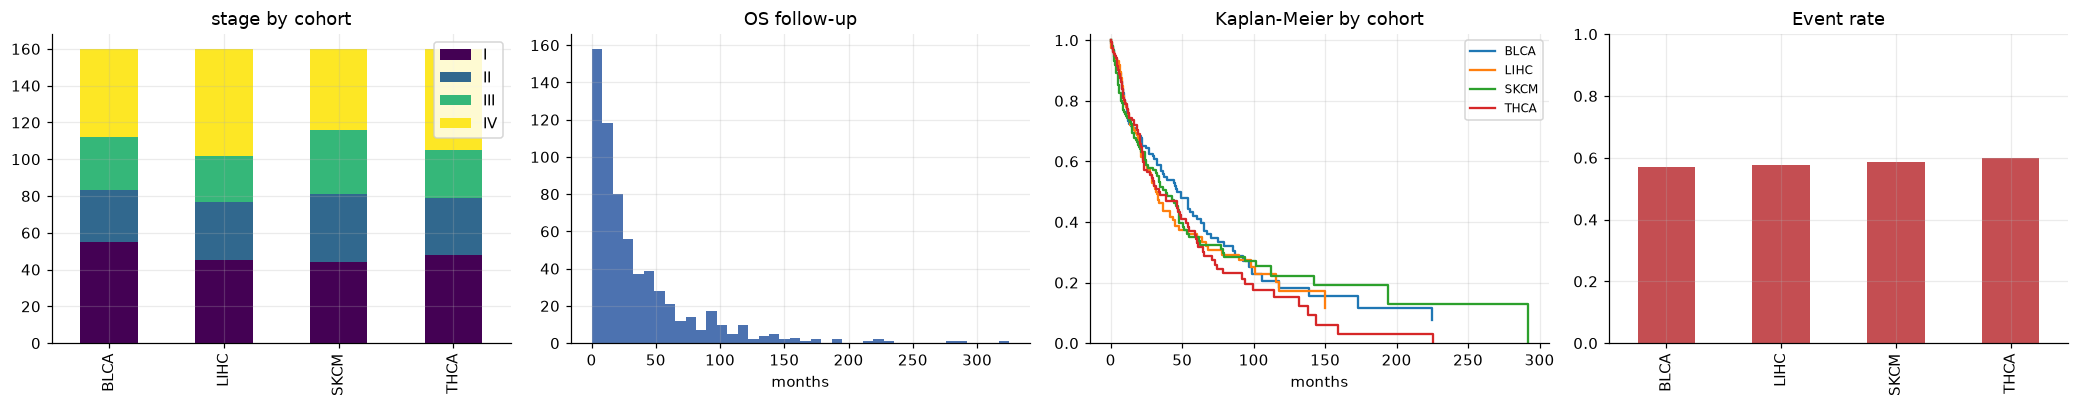

In [5]:
from mosaic.metrics import km_curve

fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))

lab = pd.DataFrame({"cohort": [sk.cohort_names[c] for c in sk.cohort_id],
                    "label": sk.label})
lab = lab[lab.label >= 0]
ct = pd.crosstab(lab.cohort, lab.label)
if CLASS_NAMES:
    ct.columns = [CLASS_NAMES[c] if c < len(CLASS_NAMES) else c for c in ct.columns]
ct.plot(kind="bar", stacked=True, ax=ax[0], colormap="viridis")
ax[0].set_title(f"{cfg.data.class_target} by cohort"); ax[0].set_xlabel("")

ax[1].hist(sk.time[np.isfinite(sk.time)], bins=40, color="#4C72B0")
ax[1].set_title(f"{cfg.data.survival_endpoint} follow-up"); ax[1].set_xlabel("months")

for ci, name in enumerate(sk.cohort_names):
    m = sk.cohort_id == ci
    t, s = km_curve(sk.time[m], np.nan_to_num(sk.event[m], nan=0))
    ax[2].step(t, s, where="post", label=name)
ax[2].set_title("Kaplan-Meier by cohort"); ax[2].set_xlabel("months")
ax[2].set_ylim(0, 1.02); ax[2].legend(fontsize=8)

ev = pd.DataFrame({"cohort": [sk.cohort_names[c] for c in sk.cohort_id],
                   "event": np.nan_to_num(sk.event, nan=0)})
ev.groupby("cohort")["event"].mean().plot(kind="bar", ax=ax[3], color="#C44E52")
ax[3].set_title("Event rate"); ax[3].set_xlabel(""); ax[3].set_ylim(0, 1)

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig1_cohorts.png", dpi=200,
                                bbox_inches="tight"); plt.show()

## 4. One fold, end to end — Table 2

`build_fold` re-fits **everything** that could leak — gene selection, the gene
graph, scalers, survival bin edges — on the training rows only. Held-out
patients are passed through `transform` and attach to training anchors in the
patient graph, never to each other.

In [6]:
from sklearn.model_selection import StratifiedKFold
from mosaic.data.preprocess import stratification_key

strat = stratification_key(sk)
idx = np.arange(len(sk))
skf = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True,
                      random_state=cfg.train.seed)
SPLITS = list(skf.split(idx, strat))
train_idx, test_idx = SPLITS[0]

inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=cfg.train.seed)
fit_i, val_i = next(inner.split(train_idx, strat[train_idx]))
fit_idx, val_idx = train_idx[fit_i], train_idx[val_i]
n_classes = max(int(sk.label.max()) + 1, 2)
print(f"train={len(fit_idx)}  val={len(val_idx)}  test={len(test_idx)}  "
      f"classes={n_classes}")

tensors, prep, data = exp.build_fold(train_idx)
BIN_EDGES = np.concatenate([[0.0], prep.surv_bins])
print(tensors.graph.summary())
print("node features:", tuple(tensors.x.shape), "| clinical:",
      tuple(tensors.clinical.shape))

train=320  val=160  test=160  classes=4


[graph] GeneGraph(genes=200, edges=240, per_relation={1: 40, 2: 200}, modules=64)
GeneGraph(genes=200, edges=240, per_relation={1: 40, 2: 200}, modules=64)
node features: (640, 200, 6) | clinical: (640, 18)


In [7]:
t0 = time.time()
model = exp.train_fold(tensors, fit_idx, val_idx, n_classes)
print(f"trained in {time.time() - t0:.0f}s")

fold_result = exp.evaluate_fold(model, tensors, test_idx, train_idx,
                                bin_edges=BIN_EDGES)
scalar = {k: v for k, v in fold_result.items()
          if isinstance(v, (int, float)) and not k.startswith("_")}
table2 = pd.DataFrame({"MOSAIC-GNN (fold 1)": scalar}).round(4)
save_table(table2, "table2_single_fold", index_label="metric")
display(table2)

  epoch  20 total=64.313 val_score=0.4339 bacc=0.288 cidx=0.580


trained in 64s


saved ./runs/table2_single_fold.csv


,MOSAIC-GNN (fold 1)
accuracy,0.3250
balanced_accuracy,0.3310
f1_macro,0.2854
f1_weighted,0.2876
precision_macro,0.3819
recall_macro,0.3310
specificity_macro,0.7768
npv_macro,0.7802
kappa,0.1045
kappa_quadratic,0.1843


In [8]:
from mosaic.metrics import per_class_report

pred = exp.predict(model, tensors, test_idx, anchor_idx=train_idx,
                   mc_samples=cfg.train.mc_dropout_samples)
y_te = tensors.label.numpy()[test_idx]
t_te = tensors.time.numpy()[test_idx]
e_te = tensors.event.numpy()[test_idx]

print("Per-class report (Table 2b)")
table2b = save_table(per_class_report(y_te, pred["prob"], CLASS_NAMES).round(3),
                     "table2b_per_class", index_label="row")
display(table2b)

print("Per-cohort breakdown (Table 2c)")
table2c = save_table(pd.DataFrame(fold_result["per_cohort"]).T.round(3),
                     "table2c_per_cohort", index_label="cohort")
display(table2c)

Per-class report (Table 2b)
saved ./runs/table2b_per_class.csv


,class,support,sensitivity,specificity,ppv,npv,f1,auroc
0,I,49,0.061,0.937,0.300,0.693,0.102,0.632
1,II,31,0.484,0.550,0.205,0.816,0.288,0.555
2,III,29,0.241,0.947,0.500,0.849,0.326,0.520
3,IV,51,0.529,0.670,0.429,0.753,0.474,0.668


Per-cohort breakdown (Table 2c)
saved ./runs/table2c_per_cohort.csv


,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,specificity_macro,npv_macro,kappa,kappa_quadratic,mcc,log_loss,brier,top2_accuracy,auroc,auprc,c_index,n
BLCA,0.225,0.232,0.196,0.189,0.238,0.232,0.748,0.743,-0.010,0.075,-0.012,1.397,0.755,0.550,0.496,0.314,0.657,40.0
LIHC,0.400,0.390,0.362,0.370,0.403,0.390,0.797,0.802,0.182,0.357,0.196,1.328,0.721,0.675,0.694,0.501,0.644,40.0
SKCM,0.300,0.308,0.235,0.231,0.274,0.308,0.769,0.775,0.074,0.106,0.090,1.373,0.743,0.575,0.582,0.337,0.510,40.0
THCA,0.375,0.399,0.335,0.346,0.437,0.399,0.795,0.805,0.176,0.195,0.201,1.357,0.735,0.650,0.625,0.415,0.650,40.0


### 4.1 Figure 2 — risk stratification

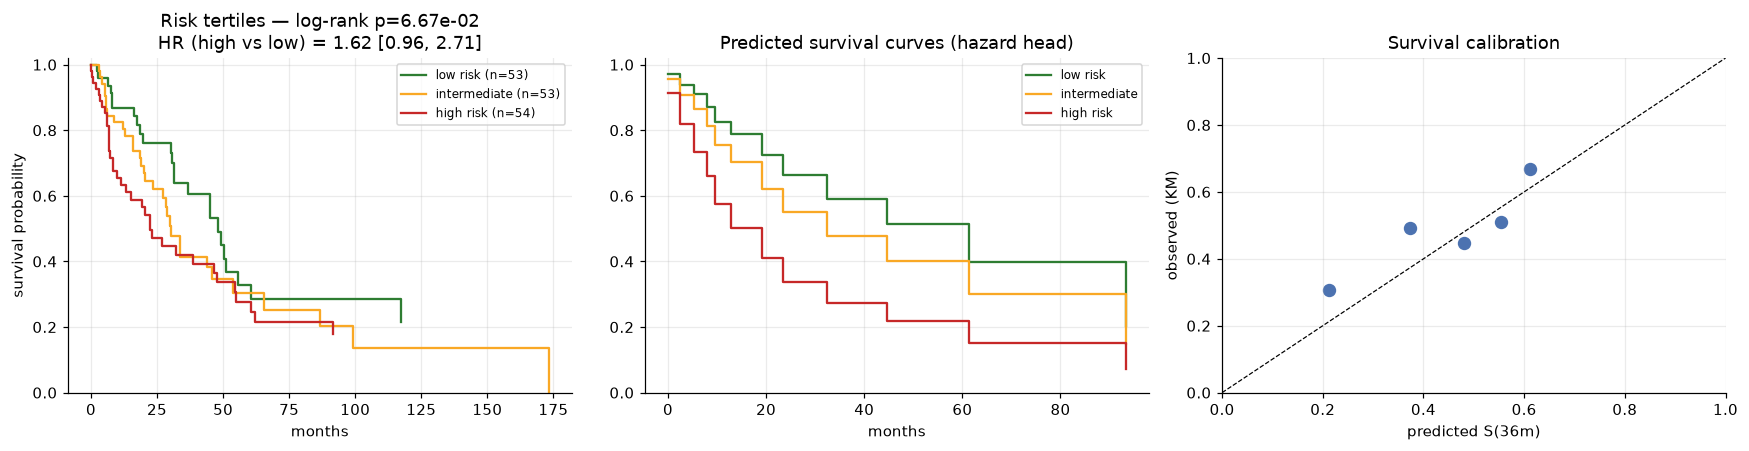

In [9]:
from mosaic.metrics import logrank_test, univariate_cox

cuts = np.quantile(pred["risk"], [1/3, 2/3])
group = np.digitize(pred["risk"], cuts)
gnames = ["low risk", "intermediate", "high risk"]
colors = ["#2E7D32", "#F9A825", "#C62828"]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for g in range(3):
    m = group == g
    if m.sum() < 5:
        continue
    tt, ss = km_curve(t_te[m], e_te[m])
    ax[0].step(tt, ss, where="post", color=colors[g],
               label=f"{gnames[g]} (n={int(m.sum())})")
hl = np.isin(group, [0, 2])
chi2, p = logrank_test(t_te[hl], e_te[hl], (group[hl] == 2).astype(int))
hr = univariate_cox(t_te[hl], e_te[hl], (group[hl] == 2).astype(float))
ax[0].set_title(f"Risk tertiles — log-rank p={p:.2e}\n"
                f"HR (high vs low) = {hr['hr']:.2f} "
                f"[{hr['hr_low']:.2f}, {hr['hr_high']:.2f}]")
ax[0].set_xlabel("months"); ax[0].set_ylabel("survival probability")
ax[0].set_ylim(0, 1.02); ax[0].legend(fontsize=8)

for g, c in zip(range(3), colors):
    m = group == g
    if m.any():
        ax[1].step(BIN_EDGES[:pred["survival"].shape[1]],
                   pred["survival"][m].mean(0), where="post", color=c,
                   label=gnames[g])
ax[1].set_title("Predicted survival curves (hazard head)")
ax[1].set_xlabel("months"); ax[1].set_ylim(0, 1.02); ax[1].legend(fontsize=8)

# observed vs predicted survival at a fixed horizon = calibration
h = 36.0
col = int(np.clip(np.searchsorted(BIN_EDGES, h, side="right") - 1, 0,
                  pred["survival"].shape[1] - 1))
predicted, observed = [], []
qs = np.quantile(pred["survival"][:, col], np.linspace(0, 1, 6))
for lo, hi in zip(qs[:-1], qs[1:]):
    m = (pred["survival"][:, col] >= lo) & (pred["survival"][:, col] <= hi)
    if m.sum() < 5:
        continue
    tt, ss = km_curve(t_te[m], e_te[m])
    observed.append(float(ss[np.searchsorted(tt, h, side="right") - 1]))
    predicted.append(float(pred["survival"][m, col].mean()))
ax[2].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[2].scatter(predicted, observed, s=60, color="#4C72B0")
ax[2].set_xlabel(f"predicted S({int(h)}m)"); ax[2].set_ylabel("observed (KM)")
ax[2].set_title("Survival calibration"); ax[2].set_xlim(0, 1); ax[2].set_ylim(0, 1)

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig2_risk.png", dpi=200,
                                bbox_inches="tight"); plt.show()

### 4.2 Figure 3 — classification quality, calibration, uncertainty

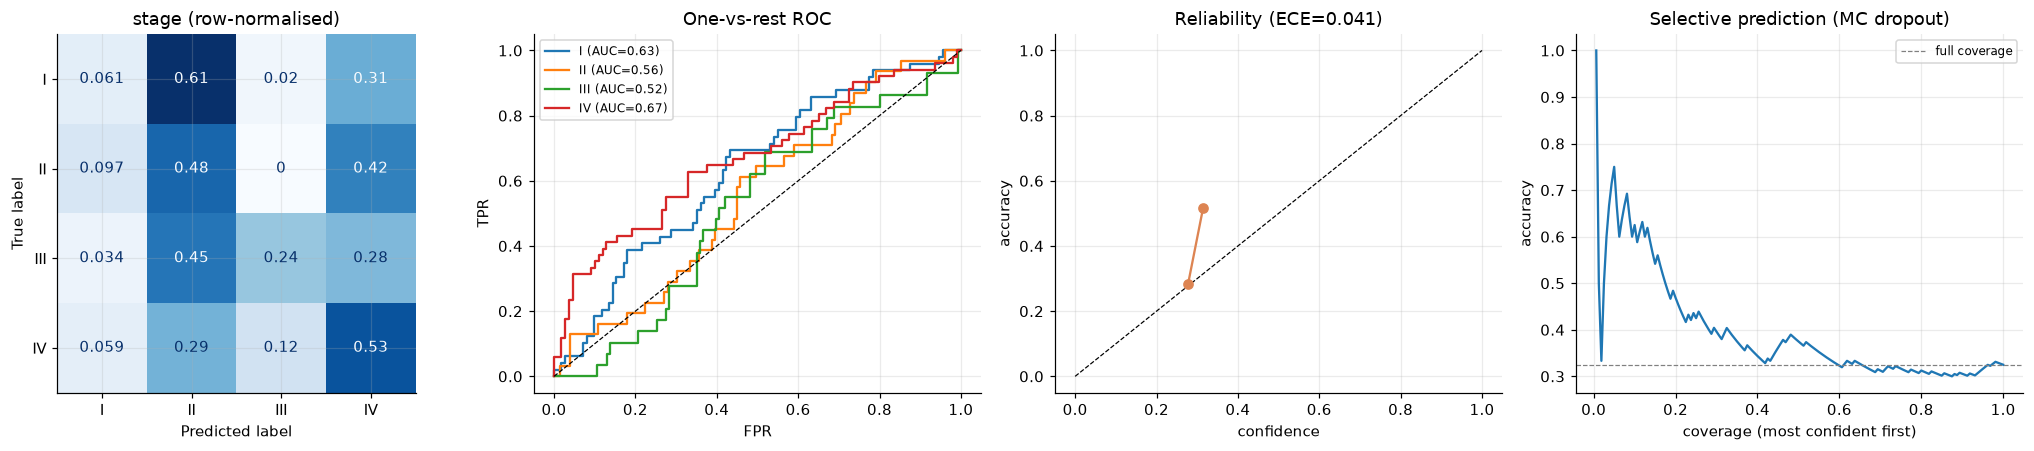

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
m = y_te >= 0

ConfusionMatrixDisplay.from_predictions(
    y_te[m], pred["prob"][m].argmax(1), normalize="true", cmap="Blues",
    colorbar=False, ax=ax[0],
    display_labels=CLASS_NAMES[:n_classes] if CLASS_NAMES else None)
ax[0].set_title(f"{cfg.data.class_target} (row-normalised)")

for c in np.unique(y_te[m]):
    fpr, tpr, _ = roc_curve((y_te[m] == c).astype(int), pred["prob"][m][:, c])
    lbl = CLASS_NAMES[c] if CLASS_NAMES and c < len(CLASS_NAMES) else c
    ax[1].plot(fpr, tpr, label=f"{lbl} (AUC={auc(fpr, tpr):.2f})")
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].set_title("One-vs-rest ROC"); ax[1].legend(fontsize=8)

# reliability diagram
conf = pred["prob"][m].max(1); correct = (pred["prob"][m].argmax(1) == y_te[m])
edges = np.linspace(0, 1, 11)
xs, ys = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    b = (conf > lo) & (conf <= hi)
    if b.sum() >= 5:
        xs.append(conf[b].mean()); ys.append(correct[b].mean())
ax[2].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[2].plot(xs, ys, "o-", color="#DD8452")
ax[2].set_xlabel("confidence"); ax[2].set_ylabel("accuracy")
ax[2].set_title(f"Reliability (ECE={scalar.get('ece', float('nan')):.3f})")

order = np.argsort(pred["entropy"][m])
corr = correct[order]
cov = np.arange(1, len(order) + 1) / len(order)
ax[3].plot(cov, np.cumsum(corr) / np.arange(1, len(order) + 1))
ax[3].axhline(corr.mean(), ls="--", c="grey", lw=0.8, label="full coverage")
ax[3].set_xlabel("coverage (most confident first)"); ax[3].set_ylabel("accuracy")
ax[3].set_title("Selective prediction (MC dropout)"); ax[3].legend(fontsize=8)

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig3_classification.png", dpi=200,
                                bbox_inches="tight"); plt.show()

## 5. Overfitting diagnostics — Tables S1-S3

With ~10^4 molecular features and a few hundred patients, "does it generalise"
is the first question a reviewer asks. Four checks answer it, and all four
belong in the supplement:

* **generalisation gap** — the same metrics on train / validation / test;
* **learning curves** — where train and validation separate, i.e. whether early
  stopping fired in the right place;
* **label permutation test** — retrain on shuffled labels; if anything leaks,
  performance stays above chance. This is the only check that can *prove* the
  absence of leakage, and it is the one most papers skip;
* **sample-size curve** — is the model data-limited or capacity-limited?

Regularisation in force: gene dropout 0.15 (whole genes are hidden each step,
value and mask channel together), input jitter, dropout 0.4, edge dropout 0.2,
weight decay 1e-3, label smoothing 0.1, gradient clipping, stochastic weight
averaging over the last 40 % of training, and early stopping on a validation
criterion that weights both tasks.

In [11]:
from mosaic.diagnostics import (generalisation_gap, learning_curves,
                                parameter_report, permutation_p_value,
                                permutation_test, sample_size_curve)

cap = parameter_report(model, len(fit_idx))
print(json.dumps({k: (round(v, 2) if isinstance(v, float) else v)
                  for k, v in cap.items()}, indent=2))

tableS1 = generalisation_gap(
    exp, tensors, model,
    {"train": fit_idx, "validation": val_idx, "test": test_idx}, train_idx)
save_table(tableS1[["balanced_accuracy", "auroc", "f1_macro", "mcc",
                    "log_loss", "brier", "c_index", "n"]].round(4),
           "tableS1_generalisation_gap", index_label="split")
display(tableS1[["balanced_accuracy", "auroc", "f1_macro", "mcc", "log_loss",
                 "brier", "c_index", "n"]].round(3))

{
  "trainable_parameters": 270238,
  "training_patients": 320,
  "parameters_per_patient": 844.49,
  "params[encoder]": 121189,
  "params[omic_proj]": 37248,
  "params[fuse]": 37120,
  "params[patient_gnn]": 33536,
  "params[hazard_head]": 13964,
  "params[cls_head]": 12932,
  "params[risk_head]": 12545,
  "params[clinical]": 672,
  "params[graph_learner]": 512,
  "params[cohort_adv]": 388,
  "params[cohort_spec]": 132
}


saved ./runs/tableS1_generalisation_gap.csv


,balanced_accuracy,auroc,f1_macro,mcc,log_loss,brier,c_index,n
train,0.306,0.618,0.236,0.114,1.349,0.730,0.672,320.0
validation,0.313,0.602,0.237,0.129,1.349,0.730,0.595,160.0
test,0.289,0.564,0.227,0.085,1.373,0.743,0.591,160.0
gap (train - test),0.018,0.054,0.010,0.029,-0.025,-0.013,0.081,NaN


saved ./runs/tableS1b_learning_curve.csv


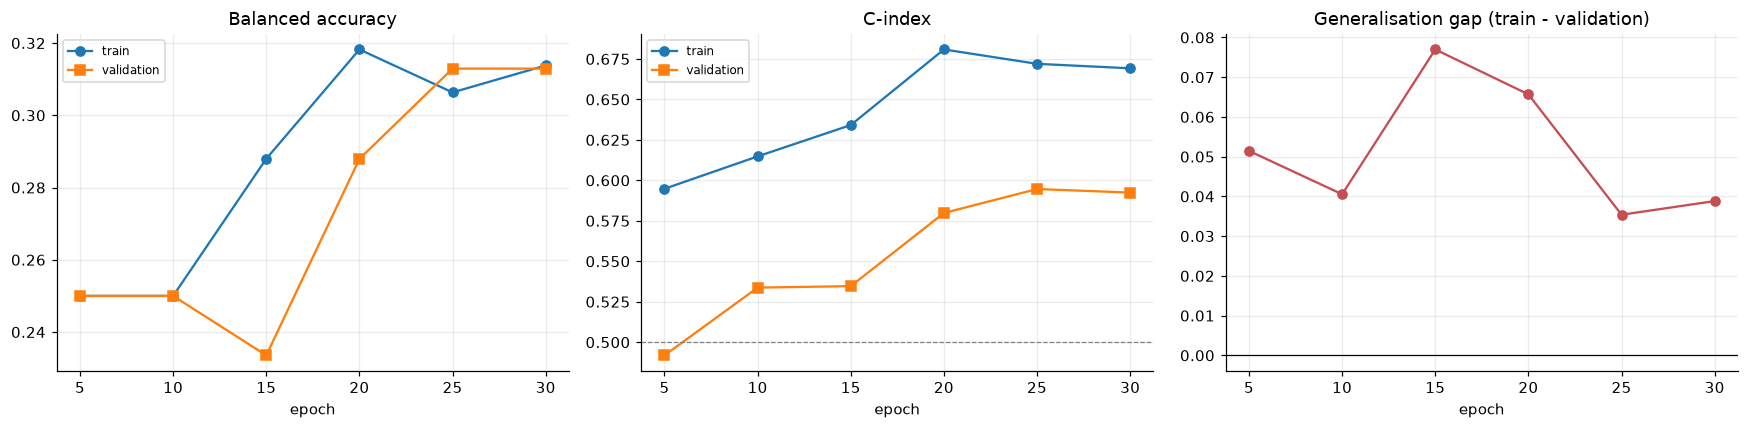

In [12]:
curves = learning_curves(model)
if not curves.empty:
    save_table(curves.round(4), "tableS1b_learning_curve", index_label="epoch")
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(curves.index, curves["train_balanced_accuracy"], "o-",
               label="train")
    ax[0].plot(curves.index, curves["val_balanced_accuracy"], "s-",
               label="validation")
    ax[0].set_title("Balanced accuracy"); ax[0].set_xlabel("epoch")
    ax[0].legend(fontsize=8)

    ax[1].plot(curves.index, curves["train_c_index"], "o-", label="train")
    ax[1].plot(curves.index, curves["val_c_index"], "s-", label="validation")
    ax[1].axhline(0.5, color="grey", ls="--", lw=0.8)
    ax[1].set_title("C-index"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)

    gap = curves["train_score"] - curves["val_score"]
    ax[2].plot(curves.index, gap, "o-", color="#C44E52")
    ax[2].axhline(0, color="k", lw=0.8)
    ax[2].set_title("Generalisation gap (train - validation)")
    ax[2].set_xlabel("epoch")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/figS1_learning_curves.png",
                                    dpi=200, bbox_inches="tight"); plt.show()

In [13]:
# The smallest attainable p-value is 1/(N_PERM + 1): 20 permutations can just
# reach p = 0.048, which is the bare minimum for a claim at alpha = 0.05.
# Use >= 100 for the manuscript (it is embarrassingly parallel across seeds).
N_PERM = 20 if RUN_FULL else 2
null = permutation_test(exp, tensors, fit_idx, val_idx, test_idx, n_classes,
                        n_permutations=N_PERM, seed=cfg.train.seed)
obs = {"balanced_accuracy": tableS1.loc["test", "balanced_accuracy"],
       "auroc": tableS1.loc["test", "auroc"],
       "c_index": tableS1.loc["test", "c_index"]}
tableS2 = pd.DataFrame({
    "observed": obs,
    "null_mean": null.mean(),
    "null_max": null.max(),
    "chance": {"balanced_accuracy": 1.0 / n_classes, "auroc": 0.5,
               "c_index": 0.5},
    "p_permutation": {k: permutation_p_value(obs[k], null[k]) for k in obs},
})
save_table(tableS2.round(4), "tableS2_permutation_test", index_label="metric")
display(tableS2.round(3))
print(f"n_permutations = {N_PERM}; the smallest attainable p is "
      f"{1 / (N_PERM + 1):.3f}")

  permutation 1/20: bacc=0.284 c-index=0.528


  permutation 2/20: bacc=0.315 c-index=0.552


  permutation 3/20: bacc=0.247 c-index=0.470


  permutation 4/20: bacc=0.272 c-index=0.537


  permutation 5/20: bacc=0.290 c-index=0.452


...

  permutation 18/20: bacc=0.269 c-index=0.463


  permutation 19/20: bacc=0.218 c-index=0.536


  permutation 20/20: bacc=0.242 c-index=0.537
saved ./runs/tableS2_permutation_test.csv


,observed,null_mean,null_max,chance,p_permutation
balanced_accuracy,0.289,0.261,0.315,0.25,0.190
auroc,0.564,0.506,0.541,0.50,0.048
c_index,0.591,0.502,0.574,0.50,0.048


n_permutations = 20; the smallest attainable p is 0.048


  n_train=  80: test bacc=0.240 test c-index=0.561


  n_train= 160: test bacc=0.257 test c-index=0.565


  n_train= 240: test bacc=0.289 test c-index=0.516


  n_train= 320: test bacc=0.287 test c-index=0.611
saved ./runs/tableS3_sample_size.csv


,train_balanced_accuracy,train_c_index,test_balanced_accuracy,test_c_index,fraction
n_train,,,,,
80,0.251,0.615,0.240,0.561,0.25
160,0.333,0.617,0.257,0.565,0.50
240,0.325,0.619,0.289,0.516,0.75
320,0.323,0.687,0.287,0.611,1.00


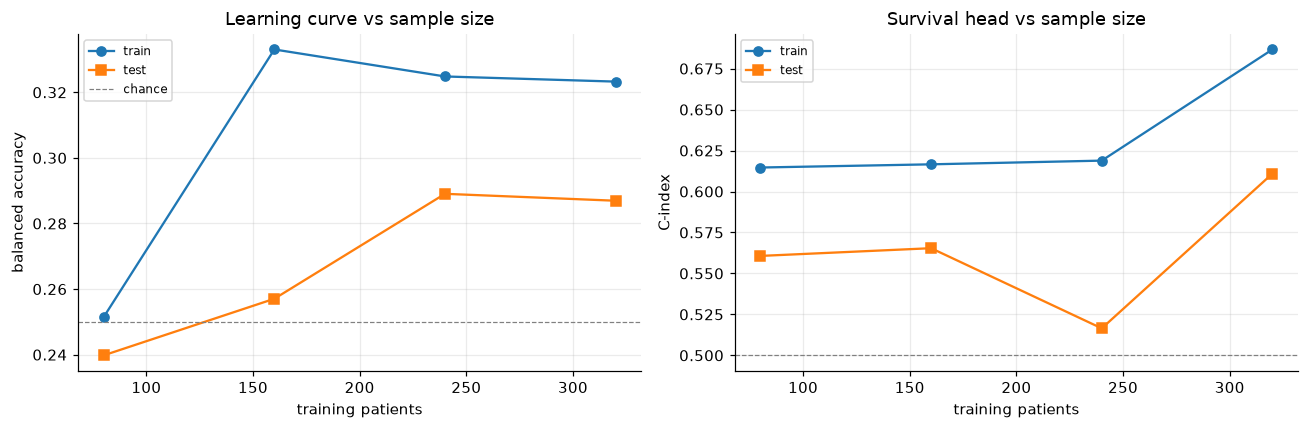

In [14]:
tableS3 = sample_size_curve(exp, tensors, fit_idx, val_idx, test_idx, n_classes,
                            fractions=(0.25, 0.5, 0.75, 1.0),
                            seed=cfg.train.seed)
save_table(tableS3.round(4), "tableS3_sample_size", index_label="n_train")
display(tableS3.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tableS3.index, tableS3["train_balanced_accuracy"], "o-", label="train")
ax[0].plot(tableS3.index, tableS3["test_balanced_accuracy"], "s-", label="test")
ax[0].axhline(1.0 / n_classes, color="grey", ls="--", lw=0.8, label="chance")
ax[0].set_xlabel("training patients"); ax[0].set_ylabel("balanced accuracy")
ax[0].set_title("Learning curve vs sample size"); ax[0].legend(fontsize=8)

ax[1].plot(tableS3.index, tableS3["train_c_index"], "o-", label="train")
ax[1].plot(tableS3.index, tableS3["test_c_index"], "s-", label="test")
ax[1].axhline(0.5, color="grey", ls="--", lw=0.8)
ax[1].set_xlabel("training patients"); ax[1].set_ylabel("C-index")
ax[1].set_title("Survival head vs sample size"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/figS2_sample_size.png", dpi=200,
                                bbox_inches="tight"); plt.show()

## 6. Head-to-head cross-validation — Table 3

MOSAIC-GNN and **every baseline are trained on identical folds**, so the
comparison is paired and a paired bootstrap test is valid. Four families of
comparator are included:

* classical predictors on concatenated features (penalised regression, SVMs,
  tree ensembles, gradient boosting, kNN, LDA, naive Bayes, PCA+logistic);
* multi-omics fusion networks (early fusion MLP, late fusion, MOGONET-style
  per-omic GCN with view fusion);
* patient-graph GNNs (GCN, GAT, GraphSAGE on a fixed kNN patient graph) — what
  most published multi-omics GNNs actually are;
* dedicated survival models (Cox-lasso, Cox-ridge, clinical-only Cox, random
  survival forest, DeepSurv).

In [15]:
from mosaic.baselines import run_baseline_suite

per_model_folds, pooled = {}, {}
BLOCKS = sorted(sk.blocks)

if RUN_FULL:
    for rep in range(REPEATS):
        splits = SPLITS if rep == 0 else list(StratifiedKFold(
            n_splits=OUTER_FOLDS, shuffle=True,
            random_state=cfg.train.seed + rep).split(idx, strat))
        for f, (tr, te) in enumerate(splits):
            print(f"\n===== repeat {rep+1}/{REPEATS} fold {f+1}/{OUTER_FOLDS} =====")
            tn, pp, dt = exp.build_fold(tr)
            edges = np.concatenate([[0.0], pp.surv_bins])

            i_fit, i_val = next(inner.split(tr, strat[tr]))
            mdl = exp.train_fold(tn, tr[i_fit], tr[i_val], n_classes, verbose=False)
            res = exp.evaluate_fold(mdl, tn, te, tr, bin_edges=edges)
            mp = exp.predict(mdl, tn, te, anchor_idx=tr)
            per_model_folds.setdefault("MOSAIC-GNN", []).append(
                {k: v for k, v in res.items() if isinstance(v, (int, float))})
            pooled.setdefault("MOSAIC-GNN", {"prob": [], "risk": [], "y": [],
                                             "t": [], "e": []})
            pooled["MOSAIC-GNN"]["prob"].append(mp["prob"])
            pooled["MOSAIC-GNN"]["risk"].append(mp["risk"])
            print(f"  {'MOSAIC-GNN':<24} bacc={res.get('balanced_accuracy', np.nan):.3f} "
                  f"auroc={res.get('auroc', np.nan):.3f} "
                  f"c-index={res.get('c_index', np.nan):.3f}")

            mets, preds = run_baseline_suite(
                tn.x.numpy(), tn.clinical.numpy(), dt.label, dt.time, dt.event,
                tr, te, n_classes, block_names=BLOCKS, seed=cfg.train.seed,
                device=str(exp.device), epochs=200 if GPU else 150)
            for name, mm in mets.items():
                per_model_folds.setdefault(name, []).append(mm)
                p = pooled.setdefault(name, {"prob": [], "risk": []})
                p["prob"].append(preds[name]["prob"])
                p["risk"].append(preds[name]["risk"])
            # truth arrays, aligned with the pooled predictions
            pooled.setdefault("_truth", {"y": [], "t": [], "e": []})
            pooled["_truth"]["y"].append(dt.label[te])
            pooled["_truth"]["t"].append(dt.time[te])
            pooled["_truth"]["e"].append(np.nan_to_num(dt.event[te], nan=0.0))
    print("\ndone")
else:
    print("RUN_FULL is False - skipping the head-to-head comparison.")


===== repeat 1/1 fold 1/4 =====


[graph] GeneGraph(genes=200, edges=240, per_relation={1: 40, 2: 200}, modules=64)


  MOSAIC-GNN               bacc=0.236 auroc=0.550 c-index=0.552


  logistic_l2              bacc=0.272 auroc=0.532 c-index=nan


  logistic_l1              bacc=0.266 auroc=0.526 c-index=nan


...

  cox_lasso                bacc=nan auroc=nan c-index=0.496


  cox_ridge                bacc=nan auroc=nan c-index=0.480


  cox_clinical_only        bacc=nan auroc=nan c-index=0.543


  random_survival_forest   bacc=nan auroc=nan c-index=0.633


  deepsurv                 bacc=nan auroc=nan c-index=0.519

done


In [16]:
table3 = table3_full = None
if per_model_folds:
    table3_full = fold_table(per_model_folds, sort_by="c_index")
    save_table(table3_full.round(4), "table3_comparison_full")
    table3 = pretty(table3_full, HEADLINE)
    save_table(table3, "table3_comparison_headline")
    display(table3)

saved ./runs/table3_comparison_full.csv
saved ./runs/table3_comparison_headline.csv


,balanced_accuracy,auroc,f1_macro,mcc,c_index,auc@36m,ibs,hr_high_vs_low
random_survival_forest,—,—,—,—,0.610 ± 0.028,0.638 ± 0.040,—,1.608 ± 0.433
MOSAIC-GNN,0.296 ± 0.046,0.569 ± 0.043,0.233 ± 0.077,0.066 ± 0.073,0.571 ± 0.044,0.569 ± 0.051,0.212 ± 0.015,1.526 ± 0.516
mogonet_style,0.328 ± 0.015,0.577 ± 0.005,0.322 ± 0.012,0.120 ± 0.026,0.564 ± 0.024,0.580 ± 0.045,—,1.561 ± 0.342
deepsurv,—,—,—,—,0.552 ± 0.030,0.554 ± 0.054,—,1.503 ± 0.251
patient_gcn,0.274 ± 0.027,0.540 ± 0.019,0.273 ± 0.027,0.044 ± 0.030,0.552 ± 0.018,0.553 ± 0.034,—,1.389 ± 0.253
patient_gat,0.296 ± 0.010,0.543 ± 0.012,0.293 ± 0.009,0.075 ± 0.014,0.547 ± 0.026,0.545 ± 0.048,—,1.412 ± 0.215
late_fusion_mlp,0.297 ± 0.029,0.557 ± 0.013,0.291 ± 0.031,0.075 ± 0.041,0.547 ± 0.021,0.555 ± 0.050,—,1.554 ± 0.192
patient_sage,0.291 ± 0.012,0.546 ± 0.013,0.287 ± 0.014,0.062 ± 0.021,0.540 ± 0.025,0.544 ± 0.054,—,1.350 ± 0.234
cox_clinical_only,—,—,—,—,0.537 ± 0.016,0.521 ± 0.031,—,1.136 ± 0.112
mlp_early_fusion,0.310 ± 0.029,0.554 ± 0.017,0.308 ± 0.030,0.088 ± 0.044,0.534 ± 0.032,0.527 ± 0.046,—,1.358 ± 0.068


In [17]:
# All classification metrics, all models.
if table3_full is not None:
    display(pretty(table3_full.sort_values("balanced_accuracy", ascending=False),
                   CLS_METRICS))

,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,specificity_macro,npv_macro,auroc,auprc,mcc,kappa,kappa_quadratic,top2_accuracy,log_loss,brier,ece
mogonet_style,0.359 ± 0.019,0.328 ± 0.015,0.322 ± 0.012,0.349 ± 0.013,0.324 ± 0.011,0.328 ± 0.015,0.780 ± 0.006,0.781 ± 0.007,0.577 ± 0.005,0.328 ± 0.018,0.120 ± 0.026,0.118 ± 0.025,0.197 ± 0.032,0.613 ± 0.031,3.442 ± 0.261,1.068 ± 0.035,0.479 ± 0.027
mlp_early_fusion,0.334 ± 0.029,0.310 ± 0.029,0.308 ± 0.030,0.330 ± 0.032,0.310 ± 0.029,0.310 ± 0.029,0.772 ± 0.012,0.773 ± 0.011,0.554 ± 0.017,0.311 ± 0.013,0.088 ± 0.044,0.088 ± 0.044,0.137 ± 0.074,0.553 ± 0.019,3.349 ± 0.114,1.112 ± 0.029,0.498 ± 0.025
lda_shrinkage,0.337 ± 0.026,0.305 ± 0.024,0.301 ± 0.023,0.328 ± 0.023,0.302 ± 0.022,0.305 ± 0.024,0.773 ± 0.009,0.774 ± 0.009,0.560 ± 0.010,0.319 ± 0.011,0.090 ± 0.034,0.089 ± 0.034,0.193 ± 0.047,0.597 ± 0.048,4.261 ± 0.288,1.128 ± 0.054,0.523 ± 0.032
xgboost,0.362 ± 0.037,0.300 ± 0.034,0.261 ± 0.033,0.309 ± 0.033,0.283 ± 0.090,0.300 ± 0.034,0.774 ± 0.013,0.782 ± 0.018,0.544 ± 0.036,0.304 ± 0.030,0.100 ± 0.059,0.094 ± 0.054,0.225 ± 0.081,0.587 ± 0.030,1.513 ± 0.063,0.799 ± 0.033,0.184 ± 0.040
late_fusion_mlp,0.328 ± 0.026,0.297 ± 0.029,0.291 ± 0.031,0.318 ± 0.030,0.293 ± 0.030,0.297 ± 0.029,0.769 ± 0.010,0.770 ± 0.010,0.557 ± 0.013,0.311 ± 0.014,0.075 ± 0.041,0.075 ± 0.041,0.155 ± 0.031,0.573 ± 0.035,2.085 ± 0.070,0.944 ± 0.015,0.356 ± 0.024
MOSAIC-GNN,0.264 ± 0.081,0.296 ± 0.046,0.233 ± 0.077,0.223 ± 0.106,0.295 ± 0.061,0.296 ± 0.046,0.766 ± 0.019,0.768 ± 0.019,0.569 ± 0.043,0.324 ± 0.035,0.066 ± 0.073,0.061 ± 0.070,0.133 ± 0.168,0.527 ± 0.076,1.377 ± 0.023,0.745 ± 0.012,0.051 ± 0.042
patient_gat,0.327 ± 0.008,0.296 ± 0.010,0.293 ± 0.009,0.319 ± 0.006,0.296 ± 0.013,0.296 ± 0.010,0.769 ± 0.004,0.770 ± 0.004,0.543 ± 0.012,0.304 ± 0.015,0.075 ± 0.014,0.074 ± 0.014,0.159 ± 0.036,0.581 ± 0.017,3.094 ± 0.157,1.097 ± 0.008,0.480 ± 0.007
random_forest,0.369 ± 0.027,0.296 ± 0.021,0.228 ± 0.021,0.282 ± 0.025,0.209 ± 0.047,0.296 ± 0.021,0.771 ± 0.009,0.780 ± 0.014,0.559 ± 0.022,0.303 ± 0.017,0.097 ± 0.043,0.083 ± 0.038,0.144 ± 0.084,0.611 ± 0.009,1.348 ± 0.005,0.730 ± 0.003,0.063 ± 0.031
lightgbm,0.350 ± 0.042,0.295 ± 0.034,0.266 ± 0.030,0.309 ± 0.034,0.270 ± 0.040,0.295 ± 0.034,0.771 ± 0.015,0.777 ± 0.020,0.550 ± 0.027,0.303 ± 0.015,0.086 ± 0.063,0.082 ± 0.059,0.190 ± 0.125,0.591 ± 0.024,2.138 ± 0.141,0.950 ± 0.045,0.368 ± 0.044
logistic_l1,0.308 ± 0.040,0.294 ± 0.033,0.293 ± 0.033,0.310 ± 0.037,0.298 ± 0.030,0.294 ± 0.033,0.768 ± 0.012,0.768 ± 0.012,0.538 ± 0.025,0.298 ± 0.017,0.069 ± 0.047,0.068 ± 0.047,0.147 ± 0.073,0.561 ± 0.043,1.485 ± 0.040,0.791 ± 0.020,0.158 ± 0.033


In [18]:
# All survival metrics, all models.
if table3_full is not None:
    display(pretty(table3_full.sort_values("c_index", ascending=False),
                   SURV_METRICS))

,c_index,c_index_lo,c_index_hi,auc@12m,auc@36m,auc@60m,ibs,brier@12m,brier@36m,brier@60m,hr_high_vs_low,hr_per_sd,logrank_chi2,logrank_p
random_survival_forest,0.610 ± 0.028,0.543 ± 0.026,0.671 ± 0.030,0.655 ± 0.050,0.638 ± 0.040,0.630 ± 0.072,—,—,—,—,1.608 ± 0.433,1.396 ± 0.177,5.885 ± 5.696,0.151 ± 0.179
MOSAIC-GNN,0.571 ± 0.044,0.505 ± 0.047,0.638 ± 0.046,0.588 ± 0.047,0.569 ± 0.051,0.568 ± 0.085,0.212 ± 0.015,0.183 ± 0.014,0.250 ± 0.008,0.239 ± 0.023,1.526 ± 0.516,1.319 ± 0.318,4.794 ± 6.581,0.238 ± 0.293
mogonet_style,0.564 ± 0.024,0.500 ± 0.029,0.629 ± 0.018,0.578 ± 0.065,0.580 ± 0.045,0.613 ± 0.052,—,—,—,—,1.561 ± 0.342,1.281 ± 0.082,5.054 ± 3.771,0.179 ± 0.322
deepsurv,0.552 ± 0.030,0.489 ± 0.027,0.618 ± 0.024,0.581 ± 0.079,0.554 ± 0.054,0.590 ± 0.043,—,—,—,—,1.503 ± 0.251,1.238 ± 0.049,4.035 ± 3.182,0.116 ± 0.139
patient_gcn,0.552 ± 0.018,0.480 ± 0.021,0.617 ± 0.017,0.579 ± 0.055,0.553 ± 0.034,0.591 ± 0.069,—,—,—,—,1.389 ± 0.253,1.219 ± 0.113,2.775 ± 2.697,0.229 ± 0.224
patient_gat,0.547 ± 0.026,0.480 ± 0.026,0.611 ± 0.021,0.576 ± 0.070,0.545 ± 0.048,0.596 ± 0.049,—,—,—,—,1.412 ± 0.215,1.205 ± 0.082,2.938 ± 2.072,0.192 ± 0.265
late_fusion_mlp,0.547 ± 0.021,0.479 ± 0.026,0.613 ± 0.017,0.557 ± 0.058,0.555 ± 0.050,0.607 ± 0.052,—,—,—,—,1.554 ± 0.192,1.208 ± 0.090,4.522 ± 2.422,0.064 ± 0.061
patient_sage,0.540 ± 0.025,0.474 ± 0.027,0.604 ± 0.020,0.565 ± 0.078,0.544 ± 0.054,0.587 ± 0.059,—,—,—,—,1.350 ± 0.234,1.193 ± 0.078,2.457 ± 1.734,0.298 ± 0.448
cox_clinical_only,0.537 ± 0.016,0.477 ± 0.016,0.597 ± 0.013,0.544 ± 0.036,0.521 ± 0.031,0.516 ± 0.033,—,—,—,—,1.136 ± 0.112,1.136 ± 0.052,0.521 ± 0.644,0.585 ± 0.296
mlp_early_fusion,0.534 ± 0.032,0.467 ± 0.035,0.598 ± 0.031,0.557 ± 0.081,0.527 ± 0.046,0.572 ± 0.046,—,—,—,—,1.358 ± 0.068,1.174 ± 0.018,2.149 ± 0.681,0.157 ± 0.081


### 6.1 Table 4 — paired bootstrap tests against MOSAIC-GNN

Predictions are pooled across folds and resampled jointly, so each test asks:
*on the same patients, is MOSAIC-GNN better than this baseline?*

In [19]:
from mosaic.metrics import (balanced_accuracy_score, concordance_index,
                            paired_bootstrap_test)

table4 = None
if pooled and "_truth" in pooled:
    y_all = np.concatenate(pooled["_truth"]["y"])
    t_all = np.concatenate(pooled["_truth"]["t"])
    e_all = np.concatenate(pooled["_truth"]["e"])
    ref = pooled["MOSAIC-GNN"]
    ref_prob = np.concatenate(ref["prob"]); ref_risk = np.concatenate(ref["risk"])

    rows = []
    for name, p in pooled.items():
        if name in ("_truth", "MOSAIC-GNN"):
            continue
        row = {"model": name}
        probs = [q for q in p["prob"] if q is not None]
        if len(probs) == len(p["prob"]):
            pb = np.concatenate(probs)
            m = y_all >= 0
            r = paired_bootstrap_test(
                lambda yy, pp_: balanced_accuracy_score(yy, pp_.argmax(1)),
                y_all[m], ref_prob[m], pb[m], n_boot=BOOTSTRAP,
                seed=cfg.train.seed)
            row.update({"d_bacc": r["delta"], "p_bacc": r["p_value"]})
        risks = [q for q in p["risk"] if q is not None]
        if len(risks) == len(p["risk"]):
            rk = np.concatenate(risks)
            stacked = np.stack([t_all, e_all], 1)
            r = paired_bootstrap_test(
                lambda te_, rr: concordance_index(te_[:, 0], rr, te_[:, 1]),
                stacked, ref_risk, rk, n_boot=BOOTSTRAP, seed=cfg.train.seed)
            row.update({"d_c_index": r["delta"], "p_c_index": r["p_value"]})
        rows.append(row)

    table4 = pd.DataFrame(rows).set_index("model")
    # Benjamini-Hochberg across the comparison family.
    for col in ("p_bacc", "p_c_index"):
        if col in table4:
            pv = table4[col].values.astype(float)
            ok = np.isfinite(pv)
            order = np.argsort(np.where(ok, pv, np.inf))
            adj = np.full_like(pv, np.nan)
            n_ok = ok.sum()
            run_min = 1.0
            for rank, i in enumerate(order[:n_ok][::-1]):
                run_min = min(run_min, pv[i] * n_ok / (n_ok - rank))
                adj[i] = run_min
            table4[col.replace("p_", "q_")] = adj
    save_table(table4.round(4), "table4_paired_tests")
    display(table4.round(4))
    print("positive delta = MOSAIC-GNN better; q = Benjamini-Hochberg adjusted")

saved ./runs/table4_paired_tests.csv


,d_bacc,p_bacc,d_c_index,p_c_index,q_bacc,q_c_index
model,,,,,,
logistic_l2,0.0125,0.645,NaN,NaN,0.8842,NaN
logistic_l1,0.0096,0.675,NaN,NaN,0.8842,NaN
logistic_elasticnet,0.0094,0.680,NaN,NaN,0.8842,NaN
linear_svm,0.0284,0.250,NaN,NaN,0.8842,NaN
svm_rbf,0.0154,0.495,NaN,NaN,0.8842,NaN
knn,0.0217,0.285,NaN,NaN,0.8842,NaN
naive_bayes,0.0585,0.005,NaN,NaN,0.1000,NaN
lda_shrinkage,-0.0017,0.930,NaN,NaN,0.9300,NaN
random_forest,0.0083,0.725,NaN,NaN,0.8842,NaN


positive delta = MOSAIC-GNN better; q = Benjamini-Hochberg adjusted


### 6.2 Figure 4 — model comparison

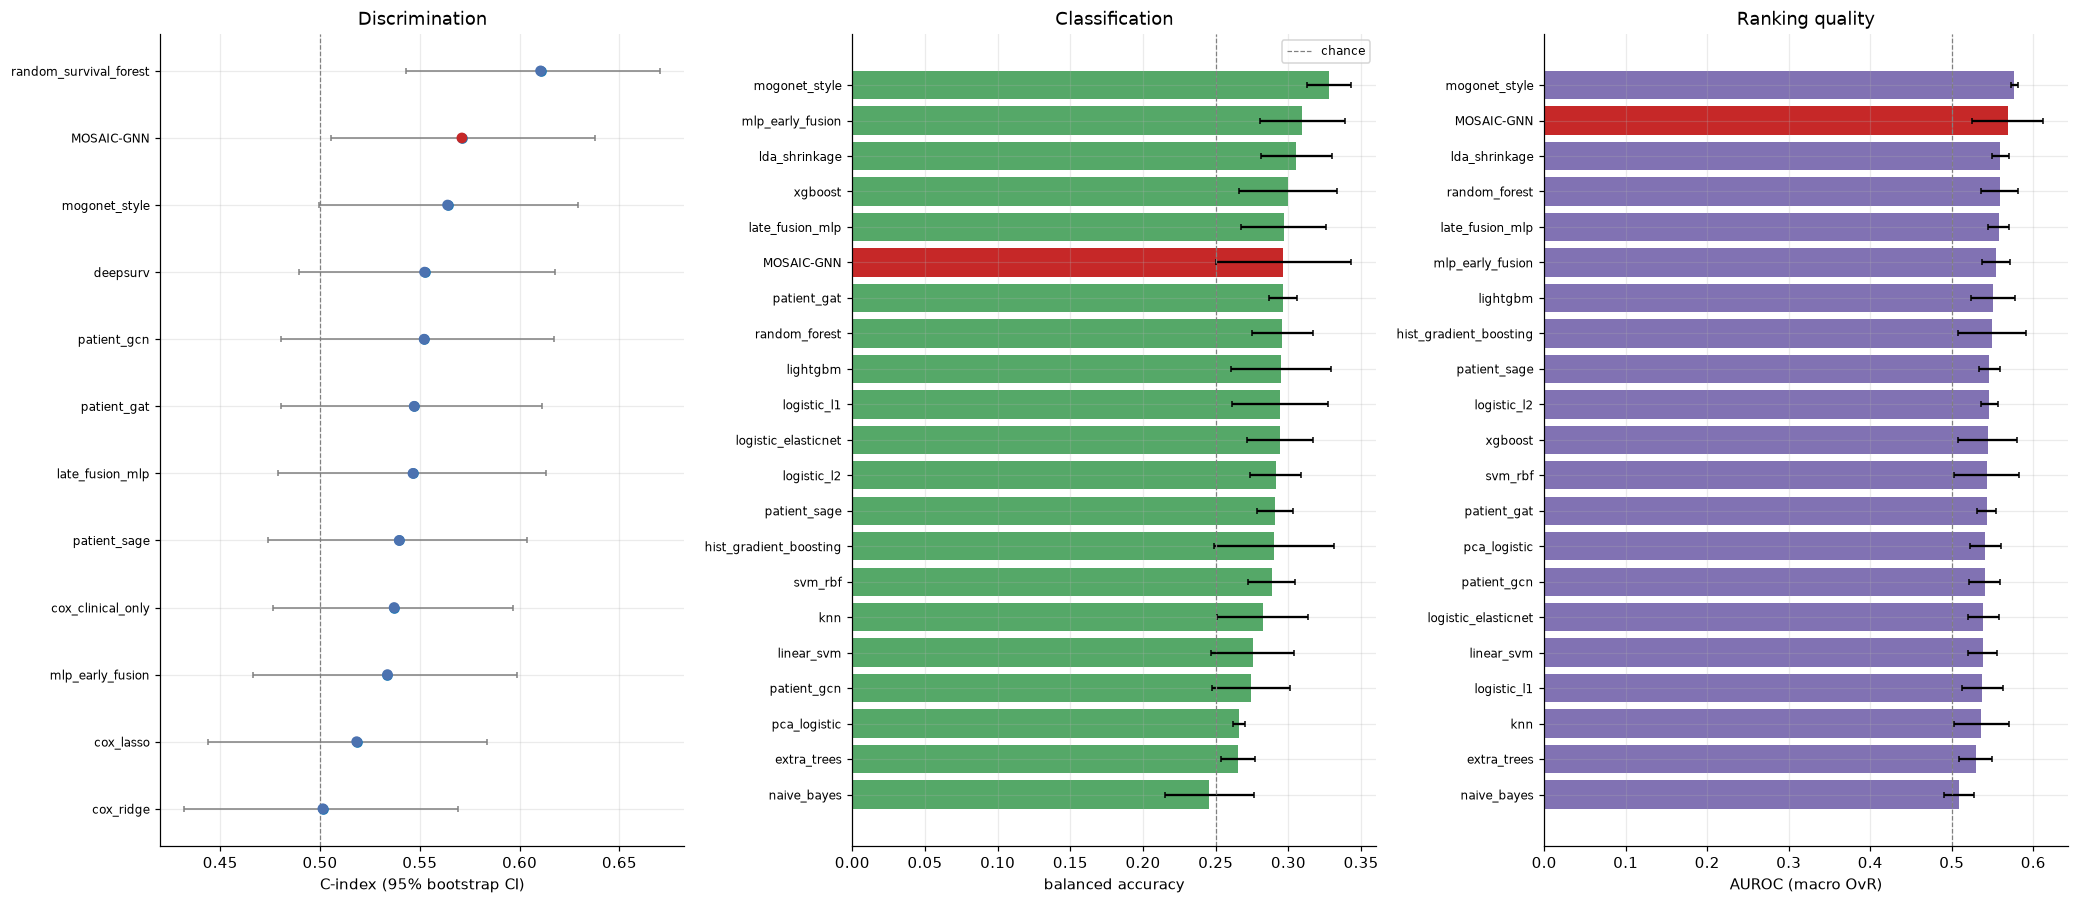

In [20]:
if table3_full is not None:
    fig, ax = plt.subplots(1, 3, figsize=(19, max(5, 0.32 * len(table3_full))))

    d = table3_full.dropna(subset=["c_index"]).sort_values("c_index")
    err = np.nan_to_num(np.abs(np.vstack([d["c_index"] - d["c_index_lo"],
                                          d["c_index_hi"] - d["c_index"]])))
    cols = ["#C62828" if i == "MOSAIC-GNN" else "#4C72B0" for i in d.index]
    ax[0].errorbar(d["c_index"], range(len(d)), xerr=err, fmt="o", ecolor="grey",
                   elinewidth=1, capsize=2, ls="none")
    ax[0].scatter(d["c_index"], range(len(d)), color=cols, zorder=3)
    ax[0].set_yticks(range(len(d))); ax[0].set_yticklabels(d.index, fontsize=8)
    ax[0].axvline(0.5, color="grey", ls="--", lw=0.8)
    ax[0].set_xlabel("C-index (95% bootstrap CI)"); ax[0].set_title("Discrimination")

    d2 = table3_full.dropna(subset=["balanced_accuracy"]).sort_values(
        "balanced_accuracy")
    cols = ["#C62828" if i == "MOSAIC-GNN" else "#55A868" for i in d2.index]
    ax[1].barh(range(len(d2)), d2["balanced_accuracy"],
               xerr=d2["balanced_accuracy_sd"], color=cols, capsize=2)
    ax[1].set_yticks(range(len(d2))); ax[1].set_yticklabels(d2.index, fontsize=8)
    ax[1].axvline(1.0 / n_classes, color="grey", ls="--", lw=0.8, label="chance")
    ax[1].set_xlabel("balanced accuracy"); ax[1].set_title("Classification")
    ax[1].legend(fontsize=8)

    d3 = table3_full.dropna(subset=["auroc"]).sort_values("auroc")
    cols = ["#C62828" if i == "MOSAIC-GNN" else "#8172B3" for i in d3.index]
    ax[2].barh(range(len(d3)), d3["auroc"], xerr=d3["auroc_sd"], color=cols,
               capsize=2)
    ax[2].set_yticks(range(len(d3))); ax[2].set_yticklabels(d3.index, fontsize=8)
    ax[2].axvline(0.5, color="grey", ls="--", lw=0.8)
    ax[2].set_xlabel("AUROC (macro OvR)"); ax[2].set_title("Ranking quality")

    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig4_comparison.png", dpi=200,
                                    bbox_inches="tight"); plt.show()

## 7. Ablations — Table 5

Each row removes exactly one component. A component earns its place in the
architecture only if removing it costs performance.

In [21]:
from mosaic.cli import ABLATIONS
from mosaic.config import Config as C

ablation_folds, table5 = {}, None
if RUN_FULL:
    for name, override in ABLATIONS.items():
        mcfg = type(cfg.model)(**{**cfg.model.__dict__, **override})
        sub = C(data=cfg.data, graph=cfg.graph, model=mcfg, loss=cfg.loss,
                train=type(cfg.train)(**cfg.train.__dict__), tag=f"abl-{name}")
        e = Experiment(sub); e.prepare()
        for f, (tr, te) in enumerate(SPLITS[:ABLATION_FOLDS]):
            tn, pp, _ = e.build_fold(tr)
            i_fit, i_val = next(inner.split(tr, strat[tr]))
            mdl = e.train_fold(tn, tr[i_fit], tr[i_val], n_classes, verbose=False)
            r = e.evaluate_fold(mdl, tn, te, tr,
                                bin_edges=np.concatenate([[0.0], pp.surv_bins]))
            ablation_folds.setdefault(name, []).append(
                {k: v for k, v in r.items() if isinstance(v, (int, float))})
        m = ablation_folds[name]
        print(f"{name:<18} bacc={np.nanmean([x.get('balanced_accuracy', np.nan) for x in m]):.3f} "
              f"c-index={np.nanmean([x.get('c_index', np.nan) for x in m]):.3f}")

    table5 = fold_table(ablation_folds)
    save_table(table5.round(4), "table5_ablation", index_label="variant")
    display(pretty(table5, HEADLINE))
else:
    print("RUN_FULL is False - skipping ablations.")

[data] patients=640 cohorts=['BLCA', 'LIHC', 'SKCM', 'THCA'] classes=4 blocks=['cna', 'exp', 'mut']
[data] survival events=373 median_followup=20.9 months


[graph] GeneGraph(genes=200, edges=240, per_relation={1: 40, 2: 200}, modules=64)


[graph] GeneGraph(genes=200, edges=246, per_relation={1: 46, 2: 200}, modules=64)


full               bacc=0.313 c-index=0.575


[data] patients=640 cohorts=['BLCA', 'LIHC', 'SKCM', 'THCA'] classes=4 blocks=['cna', 'exp', 'mut']
[data] survival events=373 median_followup=20.9 months


...

[data] patients=640 cohorts=['BLCA', 'LIHC', 'SKCM', 'THCA'] classes=4 blocks=['cna', 'exp', 'mut']
[data] survival events=373 median_followup=20.9 months


[graph] GeneGraph(genes=200, edges=240, per_relation={1: 40, 2: 200}, modules=64)


[graph] GeneGraph(genes=200, edges=246, per_relation={1: 46, 2: 200}, modules=64)


no_clinical        bacc=0.279 c-index=0.561
saved ./runs/table5_ablation.csv


,balanced_accuracy,auroc,f1_macro,mcc,c_index,auc@36m,ibs,hr_high_vs_low
full,0.313 ± 0.007,0.582 ± 0.003,0.265 ± 0.006,0.082 ± 0.016,0.575 ± 0.022,0.584 ± 0.008,0.210 ± 0.019,1.313 ± 0.049
no_gene_graph,0.289 ± 0.024,0.565 ± 0.006,0.218 ± 0.103,0.052 ± 0.032,0.527 ± 0.016,0.528 ± 0.023,0.216 ± 0.016,1.153 ± 0.096
no_module_pool,0.285 ± 0.009,0.514 ± 0.005,0.174 ± 0.019,0.046 ± 0.008,0.536 ± 0.033,0.557 ± 0.022,0.212 ± 0.019,1.315 ± 0.298
no_patient_graph,0.339 ± 0.054,0.594 ± 0.043,0.314 ± 0.083,0.125 ± 0.087,0.581 ± 0.048,0.586 ± 0.084,0.217 ± 0.020,1.203 ± 0.193
no_disentangle,0.313 ± 0.014,0.571 ± 0.035,0.293 ± 0.041,0.091 ± 0.039,0.559 ± 0.044,0.573 ± 0.051,0.217 ± 0.008,1.113 ± 0.019
no_contrast,0.324 ± 0.004,0.597 ± 0.021,0.310 ± 0.000,0.122 ± 0.004,0.597 ± 0.019,0.619 ± 0.029,0.218 ± 0.011,1.420 ± 0.554
no_clinical,0.279 ± 0.049,0.513 ± 0.057,0.196 ± 0.105,0.043 ± 0.071,0.561 ± 0.041,0.563 ± 0.050,0.215 ± 0.016,1.527 ± 0.287


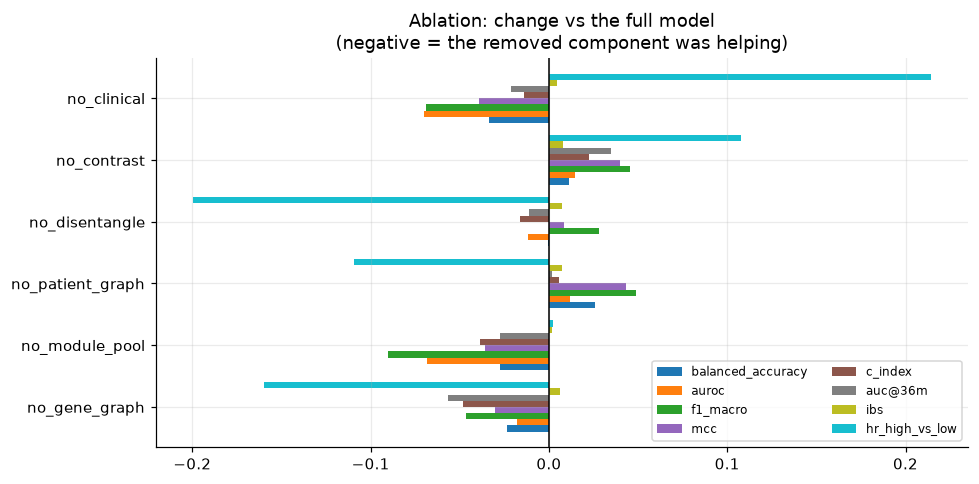

,balanced_accuracy,auroc,f1_macro,mcc,c_index,auc@36m,ibs,hr_high_vs_low
no_gene_graph,-0.0235,-0.0178,-0.0464,-0.0304,-0.0480,-0.0566,0.0061,-0.1596
no_module_pool,-0.0274,-0.0686,-0.0905,-0.0361,-0.0384,-0.0272,0.0015,0.0024
no_patient_graph,0.0256,0.0119,0.0490,0.0435,0.0057,0.0019,0.0071,-0.1092
no_disentangle,-0.0003,-0.0117,0.0282,0.0085,-0.0161,-0.0111,0.0074,-0.1998
no_contrast,0.0111,0.0147,0.0455,0.0397,0.0224,0.0351,0.0081,0.1077
no_clinical,-0.0337,-0.0698,-0.0690,-0.0390,-0.0142,-0.0213,0.0048,0.2143


In [22]:
if table5 is not None and "full" in table5.index:
    delta = table5[HEADLINE].drop(index="full") - table5.loc["full", HEADLINE]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    delta.plot(kind="barh", ax=ax, width=0.8, colormap="tab10")
    ax.axvline(0, color="k", lw=1)
    ax.set_title("Ablation: change vs the full model\n"
                 "(negative = the removed component was helping)")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig5_ablation.png", dpi=200,
                                    bbox_inches="tight"); plt.show()
    display(delta.round(4))

## 8. Leave-one-cancer-out transfer — Table 6

Train on three cohorts, test on the fourth, which the model has never seen.
This is the experiment that separates a genuine pan-cancer representation from
a cohort detector, and it is where the cohort-adversarial latent split has to
pay for itself.

[graph] GeneGraph(genes=200, edges=294, per_relation={1: 94, 2: 200}, modules=64)


BLCA   n= 160 bacc=0.248 auroc=0.453 c-index=0.525 logrank_p=6.59e-01


[graph] GeneGraph(genes=200, edges=314, per_relation={1: 114, 2: 200}, modules=64)


LIHC   n= 160 bacc=0.290 auroc=0.520 c-index=0.535 logrank_p=8.31e-02


[graph] GeneGraph(genes=200, edges=290, per_relation={1: 90, 2: 200}, modules=64)


SKCM   n= 160 bacc=0.250 auroc=0.526 c-index=0.525 logrank_p=3.29e-01


[graph] GeneGraph(genes=200, edges=322, per_relation={1: 122, 2: 200}, modules=64)


THCA   n= 160 bacc=0.299 auroc=0.550 c-index=0.518 logrank_p=8.14e-01
saved ./runs/table6_loco.csv


,balanced_accuracy,auroc,f1_macro,mcc,c_index,auc@36m,ibs,hr_high_vs_low
BLCA,0.248,0.453,0.227,-0.003,0.525,0.523,0.227,1.097
LIHC,0.290,0.520,0.250,0.050,0.535,0.539,0.215,1.443
SKCM,0.250,0.526,0.234,0.003,0.525,0.551,0.229,1.226
THCA,0.299,0.550,0.289,0.062,0.518,0.486,0.220,0.952


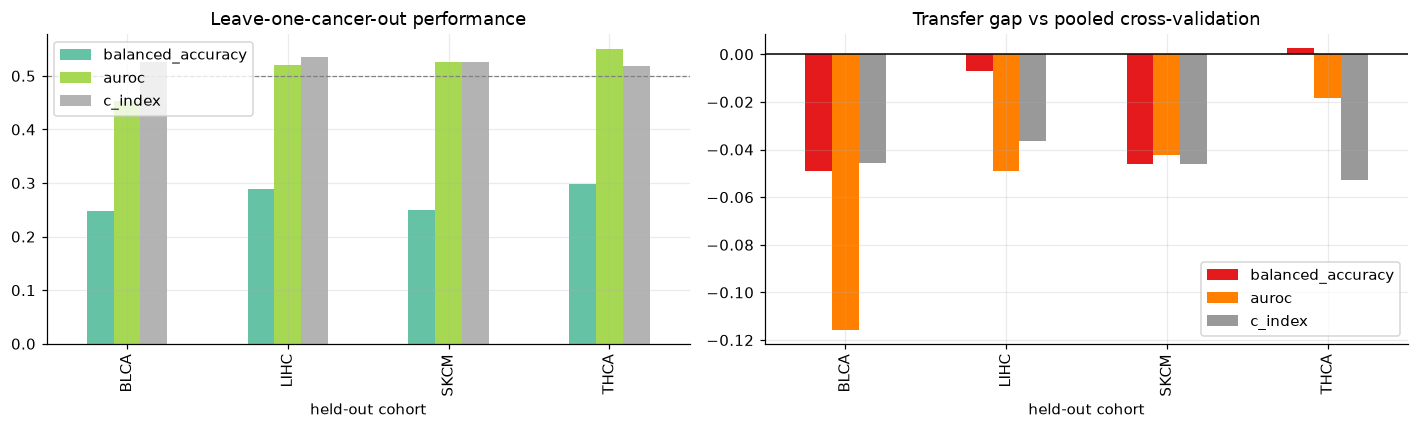

In [23]:
loco_folds, table6 = {}, None
if RUN_FULL:
    for held in cfg.data.cohorts:
        a, b = exp.offsets[held]
        te = np.arange(a, b)
        tr = np.setdiff1d(idx, te)
        rng = np.random.default_rng(cfg.train.seed)
        va = rng.choice(tr, size=max(int(0.15 * len(tr)), 20), replace=False)
        ft = np.setdiff1d(tr, va)
        tn, pp, _ = exp.build_fold(tr)
        mdl = exp.train_fold(tn, ft, va, n_classes, verbose=False)
        r = exp.evaluate_fold(mdl, tn, te, tr,
                              bin_edges=np.concatenate([[0.0], pp.surv_bins]))
        loco_folds[held] = [{k: v for k, v in r.items()
                             if isinstance(v, (int, float))}]
        print(f"{held:<6} n={len(te):4d} bacc={r.get('balanced_accuracy', np.nan):.3f} "
              f"auroc={r.get('auroc', np.nan):.3f} c-index={r.get('c_index', np.nan):.3f} "
              f"logrank_p={r.get('logrank_p', np.nan):.2e}")

    table6 = fold_table(loco_folds)
    save_table(table6.round(4), "table6_loco", index_label="held_out_cohort")
    display(table6[HEADLINE].round(3))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    table6[["balanced_accuracy", "auroc", "c_index"]].plot(
        kind="bar", ax=ax[0], colormap="Set2")
    ax[0].axhline(0.5, color="grey", ls="--", lw=0.8)
    ax[0].set_title("Leave-one-cancer-out performance"); ax[0].set_xlabel("held-out cohort")
    if table3_full is not None and "MOSAIC-GNN" in table3_full.index:
        ref = table3_full.loc["MOSAIC-GNN", ["balanced_accuracy", "auroc", "c_index"]]
        (table6[["balanced_accuracy", "auroc", "c_index"]] - ref).plot(
            kind="bar", ax=ax[1], colormap="Set1")
        ax[1].axhline(0, color="k", lw=1)
        ax[1].set_title("Transfer gap vs pooled cross-validation")
        ax[1].set_xlabel("held-out cohort")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig6_loco.png", dpi=200,
                                    bbox_inches="tight"); plt.show()
else:
    print("RUN_FULL is False - skipping leave-one-cancer-out.")

## 9. Interpretation — Tables 7 & 8

Three complementary attributions, because attention on its own is not evidence:
module attention (which pathways drive the embedding), the within-module gene
gate (which genes dominate), and integrated gradients on the node features
(signed, per-omic, baseline-referenced).

In [24]:
from mosaic.explain import (collect_attention, export_ranked_gene_list,
                            gene_importance_table, integrated_gradients,
                            module_importance_table, personalised_subnetwork)

att = collect_attention(model, tensors, test_idx, exp.device)
n_ig, ig_steps = (128, 32) if GPU else (48, 8)
ig = integrated_gradients(model, tensors, test_idx[:min(len(test_idx), n_ig)],
                          exp.device, target="risk", steps=ig_steps)

table7 = gene_importance_table(tensors.graph.genes, tensors.graph.modules,
                               tensors.graph.module_names, att["gene_gate"],
                               ig, BLOCKS)
table8 = module_importance_table(tensors.graph.module_names,
                                 att["module_attention"], tensors.graph.modules,
                                 tensors.graph.genes, gate=att["gene_gate"])
save_table(table7.round(6), "table7_gene_importance", index_label="rank")
save_table(table8.round(6), "table8_module_importance", index_label="rank")
export_ranked_gene_list(table7, f"{OUT_DIR}/genes.rnk")   # GSEA / g:Profiler
display(table7.head(25))
display(table8.head(12))

saved ./runs/table7_gene_importance.csv
saved ./runs/table8_module_importance.csv


,gene,module,gate_mean,gate_std,ig_abs,ig_cna,ig_exp,ig_mut
0,GENE0012,MODULE_011,0.299271,0.038639,0.212597,-0.001369,0.192514,-0.005488
1,GENE0270,MODULE_005,0.381770,0.050897,0.195166,-0.000238,0.154874,-0.000618
2,GENE0249,MODULE_021,0.372566,0.057280,0.175003,-0.002529,0.147477,-0.000270
3,GENE0148,MODULE_041,0.479888,0.054088,0.148641,-0.001693,0.138453,-0.000011
4,GENE0104,MODULE_020,0.481871,0.089518,0.140605,0.001303,0.106847,-0.007388
5,GENE0128,MODULE_020,0.518129,0.089518,0.134620,0.000382,0.112579,-0.001765
6,GENE0153,MODULE_039,0.367412,0.042357,0.120548,0.000286,0.087541,-0.002673
7,GENE0067,MODULE_021,0.321860,0.062278,0.111906,-0.000917,0.079899,0.000677
8,GENE0090,MODULE_041,0.520112,0.054088,0.098758,0.002661,0.059878,-0.001658
9,GENE0247,MODULE_010,0.493403,0.079472,0.096664,0.001785,0.073382,-0.000086


,module,size,attention,top_genes
0,MODULE_041,2,0.079015,"GENE0090, GENE0148"
1,MODULE_011,4,0.075005,"GENE0012, GENE0194, GENE0078, GENE0184"
2,MODULE_005,3,0.071424,"GENE0270, GENE0223, GENE0282"
3,MODULE_039,3,0.071129,"GENE0153, GENE0026, GENE0183"
4,MODULE_030,3,0.061109,"GENE0004, GENE0245, GENE0273"
5,MODULE_021,3,0.056831,"GENE0249, GENE0067, GENE0094"
6,MODULE_020,2,0.046291,"GENE0128, GENE0104"
7,MODULE_010,2,0.041920,"GENE0269, GENE0247"
8,MODULE_063,1,0.015241,GENE0231
9,MODULE_035,1,0.014085,GENE0069


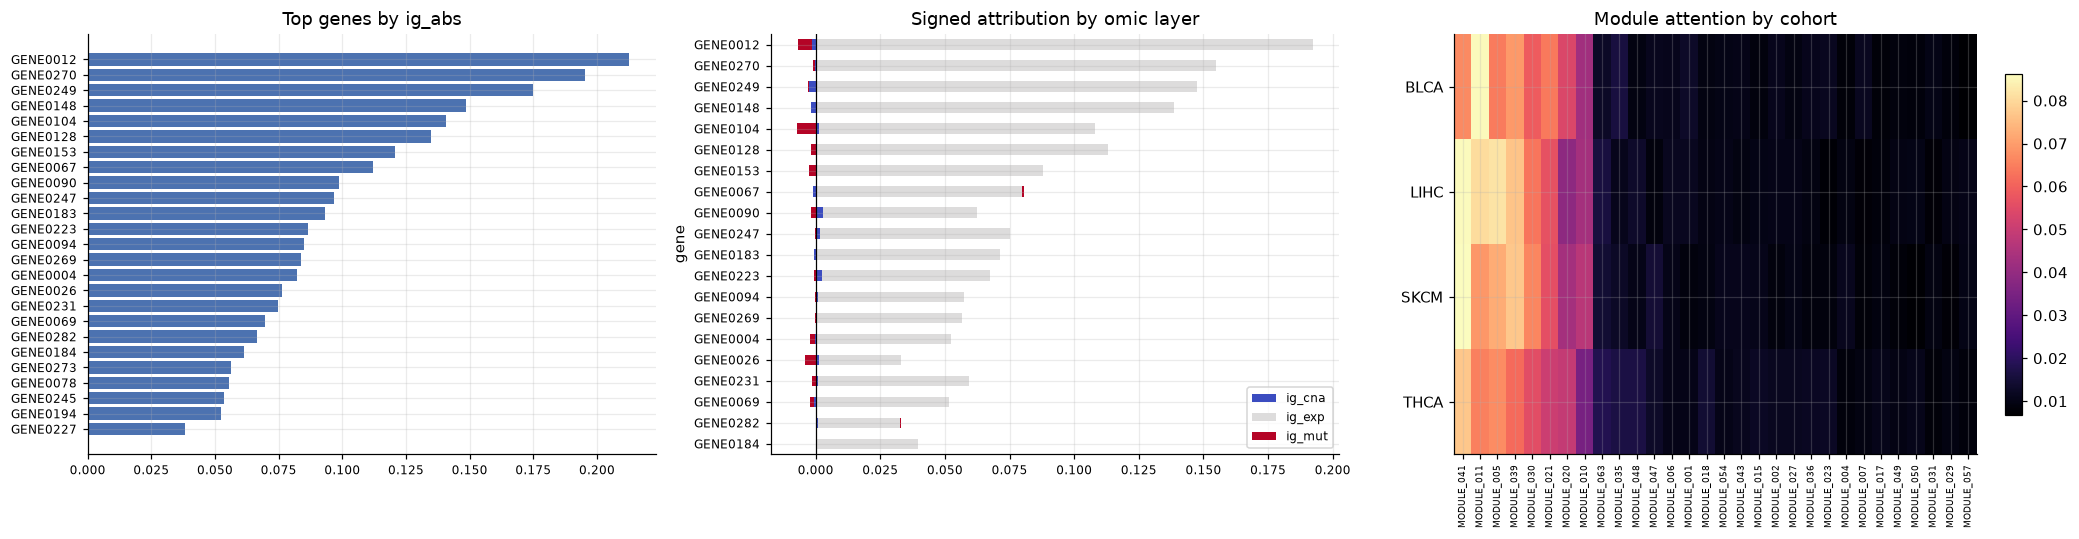

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5))

top = table7.head(25).iloc[::-1]
score_col = "ig_abs" if "ig_abs" in top else "gate_mean"
ax[0].barh(top["gene"], top[score_col], color="#4C72B0")
ax[0].set_title(f"Top genes by {score_col}"); ax[0].tick_params(labelsize=8)

ig_cols = [c for c in table7.columns if c.startswith("ig_") and c != "ig_abs"]
if ig_cols:
    tt = table7.head(20).set_index("gene")[ig_cols].iloc[::-1]
    tt.plot(kind="barh", stacked=True, ax=ax[1], colormap="coolwarm")
    ax[1].axvline(0, color="k", lw=0.8)
    ax[1].set_title("Signed attribution by omic layer")
    ax[1].tick_params(labelsize=8); ax[1].legend(fontsize=8)

coh_te = tensors.cohort.numpy()[test_idx]
present = [c for c in range(len(sk.cohort_names)) if (coh_te == c).sum() > 0]
mat = np.vstack([att["module_attention"][coh_te == c].mean(0) for c in present])
keep = np.argsort(-mat.mean(0))[:30]
im = ax[2].imshow(mat[:, keep], aspect="auto", cmap="magma")
ax[2].set_yticks(range(len(present)))
ax[2].set_yticklabels([sk.cohort_names[c] for c in present])
ax[2].set_xticks(range(len(keep)))
ax[2].set_xticklabels([tensors.graph.module_names[i] for i in keep],
                      rotation=90, fontsize=6)
ax[2].set_title("Module attention by cohort")
plt.colorbar(im, ax=ax[2], fraction=0.03)

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig7_interpretation.png", dpi=200,
                                bbox_inches="tight"); plt.show()

In [26]:
# One patient's rewired interaction network -- edge weights are that patient's
# own attention over the shared topology.
sub = personalised_subnetwork(model, tensors, int(test_idx[0]), exp.device,
                              top_edges=150)
save_table(sub.round(5), "table9_patient_subnetwork", index_label="edge")
display(sub.head(15))
print("export to Cytoscape / networkx for the subnetwork figure")

saved ./runs/table9_patient_subnetwork.csv


,source,target,attention,relation
0,GENE0191,GENE0191,1.0,2
1,GENE0083,GENE0083,1.0,2
2,GENE0019,GENE0019,1.0,2
3,GENE0221,GENE0221,1.0,2
4,GENE0259,GENE0259,1.0,2
5,GENE0178,GENE0178,1.0,2
6,GENE0053,GENE0053,1.0,2
7,GENE0151,GENE0151,1.0,2
8,GENE0069,GENE0069,1.0,2
9,GENE0170,GENE0170,1.0,2


export to Cytoscape / networkx for the subnetwork figure


## 10. Everything that was produced

In [27]:
produced = sorted(glob.glob(os.path.join(OUT_DIR, "*")))
print(f"{len(produced)} files in {OUT_DIR}\n")
for f in produced:
    print(f"  {os.path.basename(f):<40} {os.path.getsize(f) / 1024:8.1f} KB")

42 files in ./runs

  fig1_cohorts.png                            128.9 KB
  fig2_risk.png                               156.0 KB
  fig3_classification.png                     231.4 KB
  fig4_comparison.png                         283.5 KB
  fig5_ablation.png                            72.6 KB
  fig6_loco.png                                89.8 KB
  fig7_interpretation.png                     266.6 KB
  figS1_learning_curves.png                   163.8 KB
  figS2_sample_size.png                       128.9 KB
  genes.rnk                                     4.1 KB
  table1_cohorts.csv                            0.5 KB
  table1_cohorts.md                             1.1 KB
  table2_single_fold.csv                        0.6 KB
  table2_single_fold.md                         1.9 KB
  table2b_per_class.csv                         0.2 KB
  table2b_per_class.md                          0.6 KB
  table2c_per_cohort.csv                        0.6 KB
  table2c_per_cohort.md                      

## 11. Before you write it up

- Report **mean ± sd over ≥ 3 repeats × 5 folds** (`REPEATS = 3`,
  `OUTER_FOLDS = 5`); the settings above are tuned to finish quickly.
- Baselines were tuned on the *same* inner splits — say so explicitly.
- Table 4 gives the **paired bootstrap** p-values with Benjamini-Hochberg
  correction; quote the adjusted `q`, not the raw `p`.
- Show **per-cohort** numbers (Table 2c) next to the pooled figure.
- Report the **leave-one-cancer-out** result even where it is weak — it is the
  honest measure of "pan-cancer".
- Cross-check the top-ranked genes (Table 7) against COSMIC CGC / OncoKB and
  present the novel ones as **hypotheses**, not findings.
- State the limitations: cohort sizes in the hundreds → wide survival CIs; the
  co-alteration fallback graph is not a validated interaction network; and
  attention-derived rankings need orthogonal validation.